In [1]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio

import torchaudio
import torch 
from torch.utils.data import Dataset, DataLoader
from transformers import Wav2Vec2Model, Wav2Vec2Processor, Trainer, TrainingArguments, Wav2Vec2ForSequenceClassification

import warnings
warnings.filterwarnings('ignore')

C:\anaconda\envs\emotiongpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch
print(f"Is CUDA available? {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")


Is CUDA available? True
GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
import torch
import torchaudio

print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print("Torchaudio:", torchaudio.__version__)

CUDA: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Torchaudio: 2.10.0+cpu


## Loading the Dataset

In [4]:
crema_path= ('C:/Users/HP/anaconda_projects/megaproject/Datasets/Crema/AudioWAV')


crema_paths = []
crema_labels = []

emotion_map = {
    "ANG": "angry",
    "DIS": "disgust",
    "FEA": "fear",
    "HAP": "happy",
    "NEU": "neutral",
    "SAD": "sad"
}

for dirname, _, filenames in os.walk(crema_path):
    for filename in filenames:
        
        parts = filename.split("_")
        emotion_code = parts[2]
        emotion = emotion_map[emotion_code]
        if emotion != 'calm':
            crema_paths.append(os.path.join(dirname, filename))
            crema_labels.append(emotion)
        
print('Dataset is loaded')

Dataset is loaded


In [5]:
'''tess_path = "C:/Users/HP/anaconda_projects/megaproject/Datasets/TESS/TESS Toronto emotional speech set data"

tess_paths = []
tess_labels = []
for dirname, _, filenames in os.walk(tess_path):
    for filename in filenames:
        tess_paths.append(os.path.join(dirname, filename))
        label = filename.split('_')[-1]
        label= label.split('.')[0]
        tess_labels.append(label.lower())
        
print('Dabtaset is loaded')'''

'tess_path = "C:/Users/HP/anaconda_projects/megaproject/Datasets/TESS/TESS Toronto emotional speech set data"\n\ntess_paths = []\ntess_labels = []\nfor dirname, _, filenames in os.walk(tess_path):\n    for filename in filenames:\n        tess_paths.append(os.path.join(dirname, filename))\n        label = filename.split(\'_\')[-1]\n        label= label.split(\'.\')[0]\n        tess_labels.append(label.lower())\n        \nprint(\'Dabtaset is loaded\')'

In [6]:
ravdess_path = "C:/Users/HP/anaconda_projects/megaproject/Datasets/RAVDESS"

ravdess_paths = []
ravdess_labels = []

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fear",
    "07": "disgust",
    "08": "ps"
}

for dirname, _, filenames in os.walk(ravdess_path):
    for filename in filenames:
        parts = filename.split("-")
        emotion_code = parts[2]
        emotion = emotion_map[emotion_code]
        if emotion != 'calm':
            ravdess_paths.append(os.path.join(dirname, filename))
            ravdess_labels.append(emotion)

print('Dataset is loaded')

Dataset is loaded


In [7]:
paths =  ravdess_paths + crema_paths #+ tess_paths
labels =  ravdess_labels + crema_labels #+ tess_labels

In [8]:
paths[:3]

['C:/Users/HP/anaconda_projects/megaproject/Datasets/RAVDESS\\Actor_01\\03-01-01-01-01-01-01.wav',
 'C:/Users/HP/anaconda_projects/megaproject/Datasets/RAVDESS\\Actor_01\\03-01-01-01-01-02-01.wav',
 'C:/Users/HP/anaconda_projects/megaproject/Datasets/RAVDESS\\Actor_01\\03-01-01-01-02-01-01.wav']

In [9]:
labels[:5]

['neutral', 'neutral', 'neutral', 'neutral', 'happy']

In [10]:
## creating a dataframe
df = pd.DataFrame()
df['audio_paths'] = paths
df['labels'] = labels
df.head()

,audio_paths,labels
0,C:/Users/HP/anaconda_projects/megaproject/Data...,neutral
1,C:/Users/HP/anaconda_projects/megaproject/Data...,neutral
2,C:/Users/HP/anaconda_projects/megaproject/Data...,neutral
3,C:/Users/HP/anaconda_projects/megaproject/Data...,neutral
4,C:/Users/HP/anaconda_projects/megaproject/Data...,happy


<Axes: xlabel='labels', ylabel='count'>

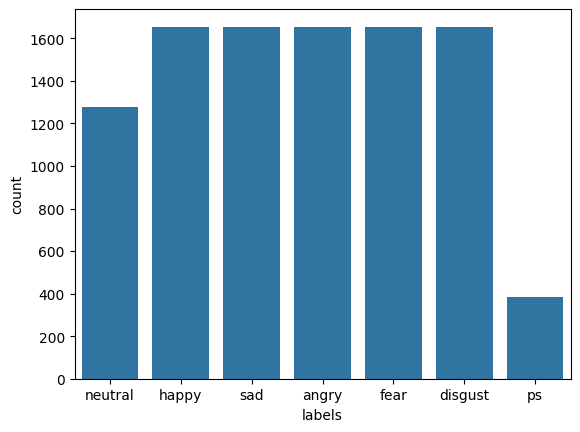

In [11]:
sns.countplot(data=df, x='labels')

In [12]:
df['labels'].value_counts()

labels
happy      1655
sad        1655
angry      1655
disgust    1655
fear       1655
neutral    1279
ps          384
Name: count, dtype: int64

In [13]:
def waveplot(data, sr, emotion):
    plt.figure(figsize = (10, 4))
    plt.title(emotion, size=20)
    librosa.display.waveshow(data, sr = sr)
    plt.show()

def spectogram(data, sr, emotion):
    x= librosa.stft(data)
    xdb = librosa.amplitude_to_db(abs(x))
    plt.figure(figsize = (10, 4))
    plt.title(emotion, size=20)
    librosa.display.specshow(xdb , sr = sr, x_axis = 'time', y_axis= 'hz')
    plt.colorbar()

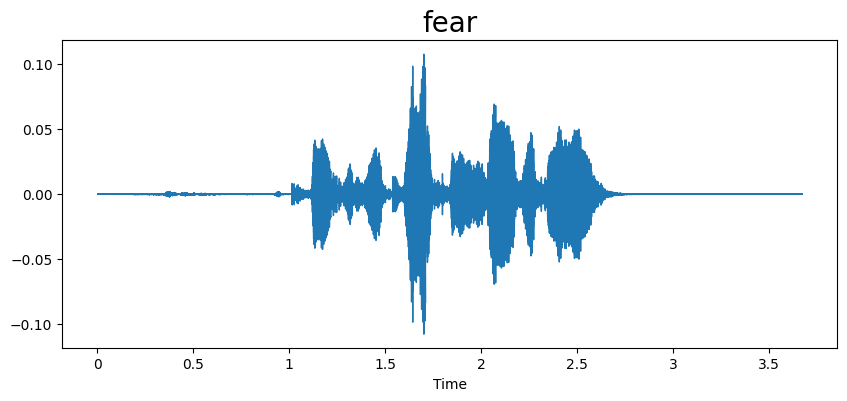

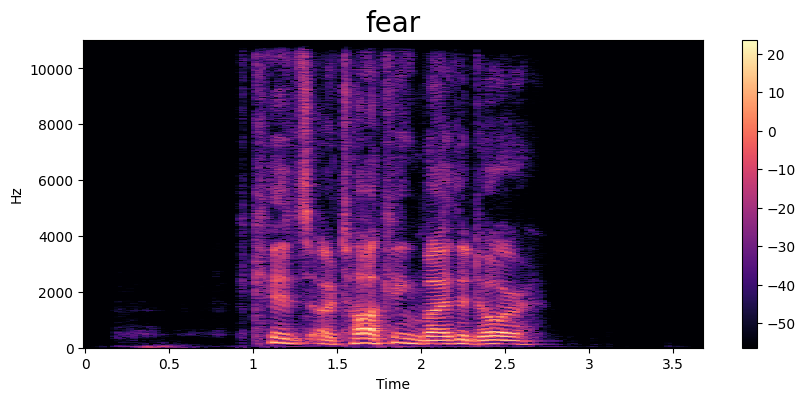

In [14]:
emotion = 'fear'
path = np.array(df['audio_paths'][df['labels'] == emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

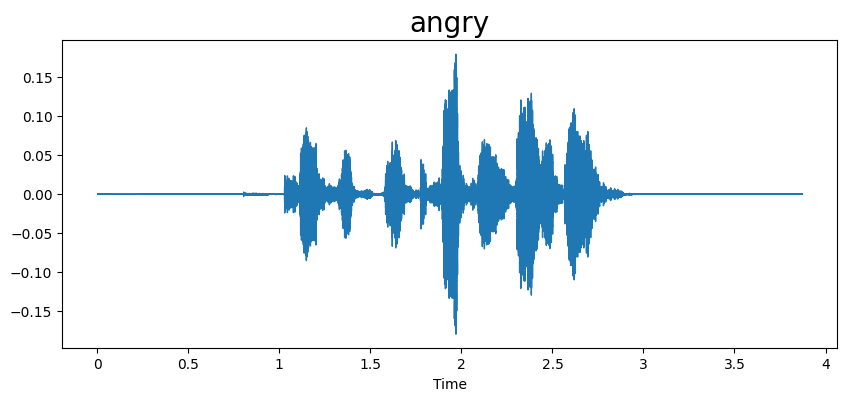

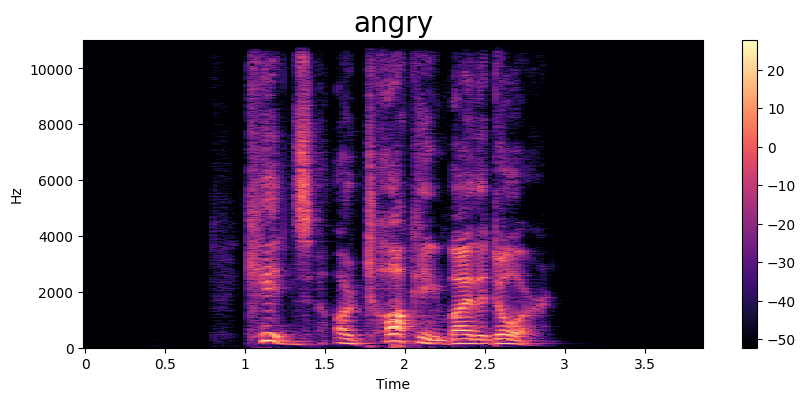

In [15]:
emotion = 'angry'
path = np.array(df['audio_paths'][df['labels'] == emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

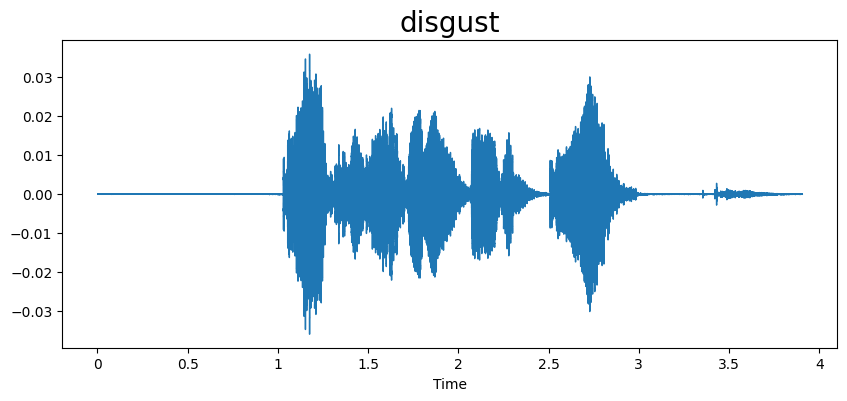

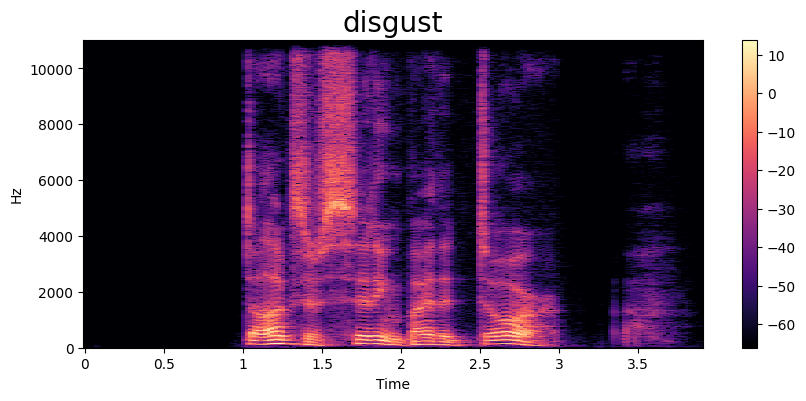

In [16]:
emotion = 'disgust'
path = np.array(df['audio_paths'][df['labels'] == emotion])[2]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

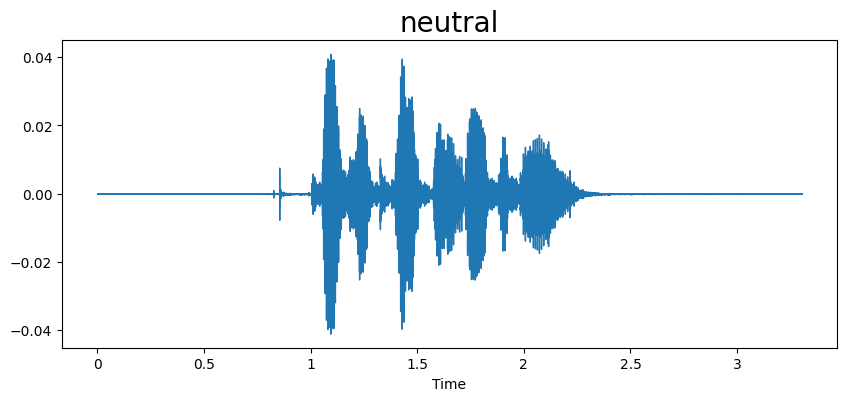

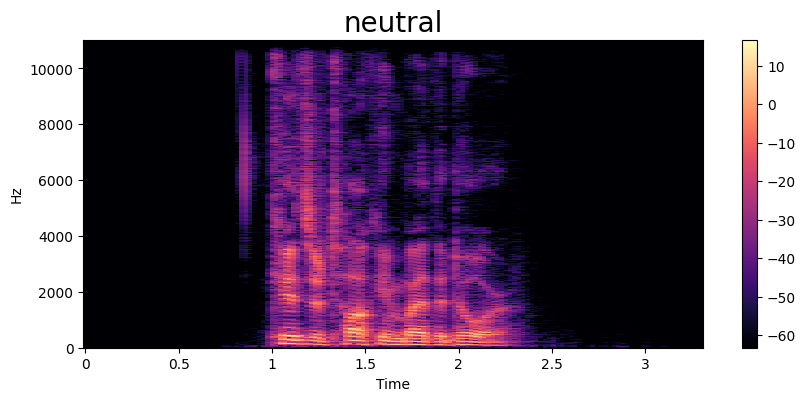

In [17]:
emotion = 'neutral'
path = np.array(df['audio_paths'][df['labels'] == emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

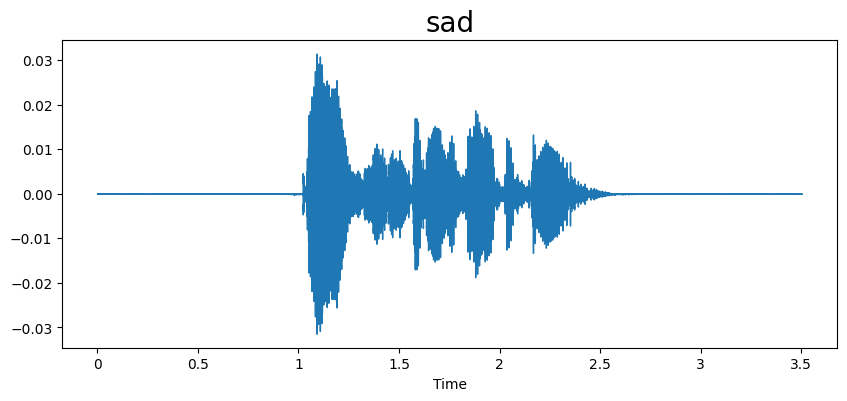

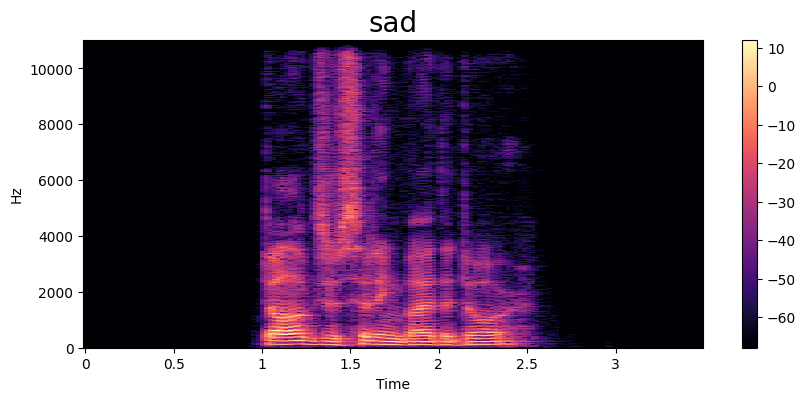

In [18]:
emotion = 'sad'
path = np.array(df['audio_paths'][df['labels'] == emotion])[2]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

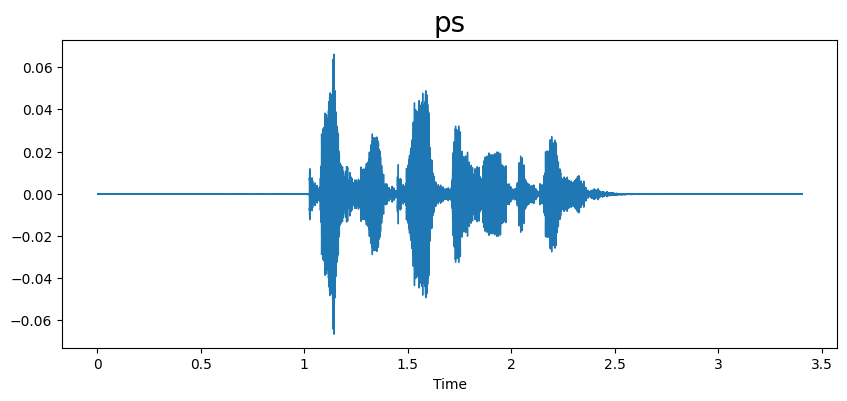

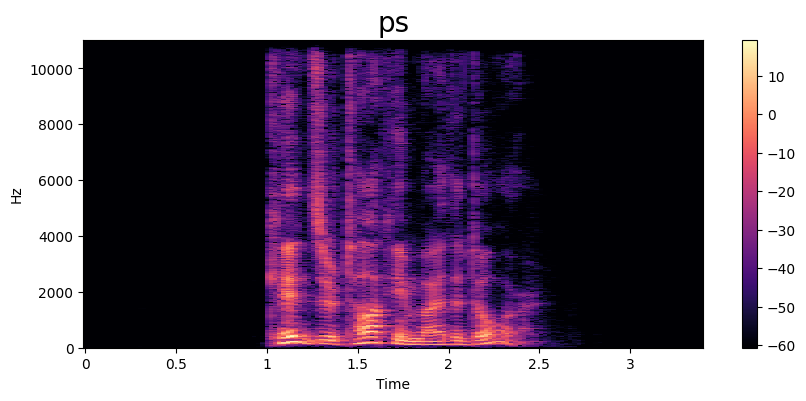

In [19]:
emotion = 'ps'
path = np.array(df['audio_paths'][df['labels'] == emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

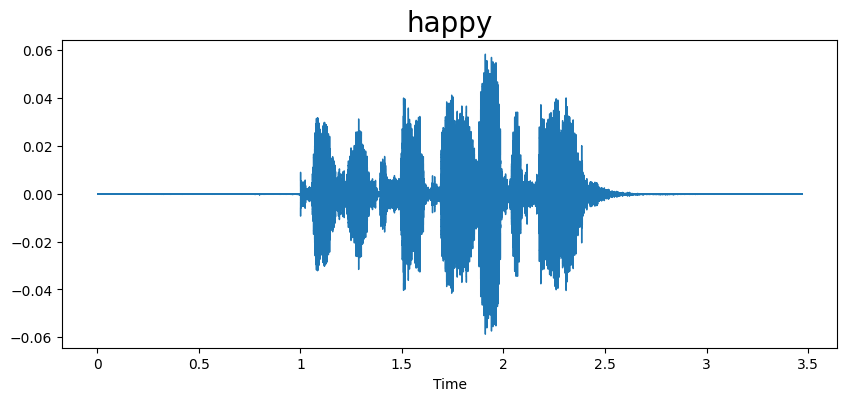

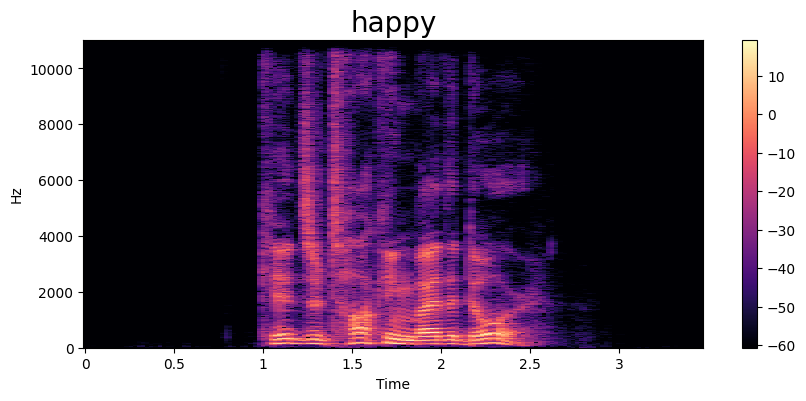

In [20]:
emotion = 'happy'
path = np.array(df['audio_paths'][df['labels'] == emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

# **Creating Custom Dataset Class**

In [21]:
#convert labels to integers
label_map = {label: idx for idx, label in enumerate(df['labels'].unique())}
inverse_label_map = {idx: label for label, idx in label_map.items()}
df['labels'] = df['labels'].map(label_map)
df.head(2)

,audio_paths,labels
0,C:/Users/HP/anaconda_projects/megaproject/Data...,0
1,C:/Users/HP/anaconda_projects/megaproject/Data...,0


In [22]:
class SpeechEmotionDataset(Dataset):
    def __init__(self, df, processor, max_length = 44100):
        self.df= df
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        audio_path = self.df.iloc[idx]['audio_paths']
        label = self.df.iloc[idx]['labels']

        #load the audio file
        speech,sr = librosa.load(audio_path, sr=16000)

        #pad or truncade the speech to required length
        if len(speech)>self.max_length:
                speech = speech[:self.max_length]
        else:
            speech = np.pad(speech, (0, self.max_length - len(speech)), 'constant')

        #preprocessing the audio file
        inputs = self.processor(speech, sampling_rate = 16000, return_tensors = 'pt', padding = True, truncate = True, max_length = self.max_length)

        input_values = inputs.input_values.squeeze()
        return{'input_values': input_values, 'labels': torch.tensor(label, dtype = torch.long)}

In [23]:
#split The data for train and test
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['labels']
)

In [24]:
#initiating the processor and model
processor = Wav2Vec2Processor.from_pretrained('facebook/wav2vec2-base')
model = Wav2Vec2ForSequenceClassification.from_pretrained('facebook/wav2vec2-base', num_labels = 7)

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 9577.18it/s]
Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_q.weight             | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
projector.bias               | MISSING    | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 
projector.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [25]:
#load the dataset
train_dataset = SpeechEmotionDataset(train_df,processor)
test_dataset = SpeechEmotionDataset(test_df,processor)

In [26]:
train_dataset[0]['input_values'].size()

Keyword argument `truncate` is not a valid argument for this processor and will be ignored.


torch.Size([44100])

## Setting Training Arguments

In [27]:
training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy = 'epoch',
    save_strategy= 'epoch',
    learning_rate = 2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay = 0.01,
    report_to=[]
)

In [28]:
#create functions for computing metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids #original labels
    preds = np.argmax(pred.predictions,axis=1) #model predicted labels
    accuracy = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average= 'weighted')
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [29]:
#initialize the trainer
trainer = Trainer(
    model = model, 
    args = training_args,
    train_dataset =train_dataset,
    eval_dataset =test_dataset,
    compute_metrics = compute_metrics
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,1.013378,0.690644,0.696074,0.690644,0.688681
2,1.443712,0.764187,0.743964,0.746787,0.743964,0.743730
3,0.891519,0.691948,0.773642,0.780855,0.773642,0.770074
4,0.640218,0.594268,0.815895,0.822020,0.815895,0.816951
5,0.484695,0.607352,0.809356,0.811471,0.809356,0.808793


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.19s/it]


TrainOutput(global_step=2485, training_loss=0.7729022941359092, metrics={'train_runtime': 2343.0514, 'train_samples_per_second': 16.965, 'train_steps_per_second': 1.061, 'total_flos': 9.9467701869375e+17, 'train_loss': 0.7729022941359092, 'epoch': 5.0})

In [31]:
#results = trainer.evaluate()
#print(results)

In [38]:
#from transformers.trainer_callback import PrinterCallback

# Remove the buggy progress bar that causes the crash
#trainer.remove_callback(trainer.pop_callback(transformers.trainer_callback.NotebookProgressCallback))

# Now evaluate safely
#results = trainer.evaluate()
#print(results)


## Test Predictions

In [33]:
import random
idx = random.randrange(0, len(test_dataset))
print("Original Label:", inverse_label_map[int(test_dataset[idx]['labels'])])
input_values = test_dataset[idx]['input_values'].unsqueeze(0).to('cuda')

with torch.no_grad():
    outputs = model(input_values)
logits = outputs.logits

predicted_class = logits.argmax(dim=-1).item()
print('Predicted Label:',inverse_label_map[predicted_class])

Original Label: disgust
Predicted Label: disgust


In [34]:
idx = random.randrange(0, len(test_dataset))
print("Original Label:", inverse_label_map[int(test_dataset[idx]['labels'])])
input_values = test_dataset[idx]['input_values'].unsqueeze(0).to('cuda')

with torch.no_grad():
    outputs = model(input_values)
logits = outputs.logits

predicted_class = logits.argmax(dim=-1).item()
print('Predicted Label:',inverse_label_map[predicted_class])

Original Label: fear
Predicted Label: sad


In [35]:
test_path='C:/Users/HP/anaconda_projects/megaproject/Datasets/RAVDESS/Actor_02/03-01-01-01-01-02-02.wav'

class SpeechEmotionDataset(Dataset):
    def __init__(self, df, processor, max_length = 44100):
        self.df= df
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        audio_path = self.df.iloc[idx]['audio_paths']
        speech,sr = librosa.load(test_path, sr=16000)

        #pad or truncade the speech to required length
        if len(speech)>self.max_length:
                speech = speech[:self.max_length]
        else:
            speech = np.pad(speech, (0, self.max_length - len(speech)), 'constant')

        #preprocessing the audio file
        inputs = self.processor(speech, sampling_rate = 16000, return_tensors = 'pt', padding = True, truncate = True, max_length = self.max_length)

        input_values = inputs.input_values.squeeze()
input_values = test_dataset[idx]['input_values'].unsqueeze(0).to('cuda')

with torch.no_grad():
    outputs = model(input_values)
logits = outputs.logits

predicted_class = logits.argmax(dim=-1).item()
print('Predicted Label:',inverse_label_map[predicted_class])

Predicted Label: sad


In [36]:
trainer.save_model("./saved_model")
processor.save_pretrained("./saved_model")

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.01s/it]


['./saved_model\\processor_config.json']

In [37]:
print([inverse_label_map[i] for i in range(len(inverse_label_map))])

['neutral', 'happy', 'sad', 'angry', 'fear', 'disgust', 'ps']
